In [311]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [312]:
#DATASET CARGADO DE LA NUBE GRACIAS A SEABORN
propinas = sns.load_dataset("tips")
propinas

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

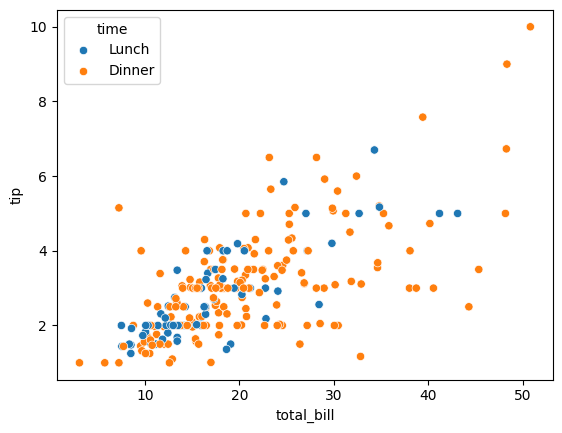

In [313]:
sns.scatterplot(data=propinas, x="total_bill", y="tip", hue="time")

<Axes: xlabel='total_bill', ylabel='tip'>

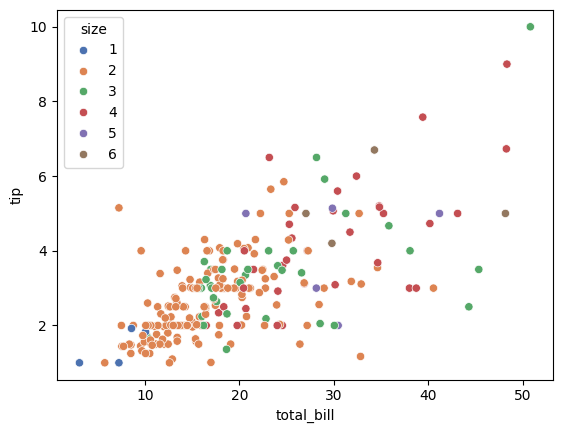

In [314]:
#ASIGNAR OTRA VARIABLE CATEGORICA PARA PODER TENER MAS ELEMENTOS DE INTERPRETACION
sns.scatterplot(data=propinas, x="total_bill", y="tip", hue="size", palette="deep")

<Axes: xlabel='total_bill', ylabel='tip'>

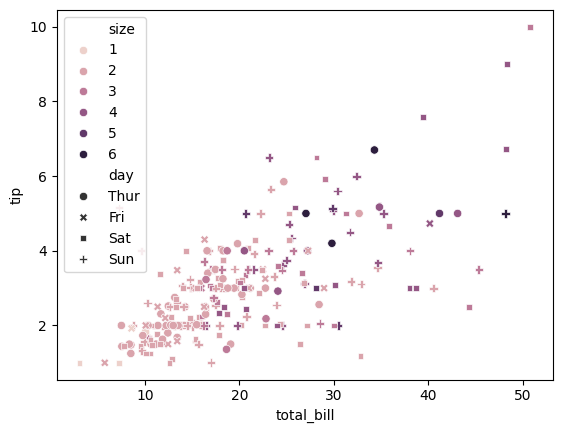

In [315]:
sns.scatterplot(data=propinas, x="total_bill", y="tip", hue="size", style="day")

In [316]:
#METODO UNIQUE PARA DEVOLVER UNA SOLA COLUMNA DEL DATASET
propinas["tip"].unique()

array([ 1.01,  1.66,  3.5 ,  3.31,  3.61,  4.71,  2.  ,  3.12,  1.96,
        3.23,  1.71,  5.  ,  1.57,  3.  ,  3.02,  3.92,  1.67,  3.71,
        3.35,  4.08,  2.75,  2.23,  7.58,  3.18,  2.34,  4.3 ,  1.45,
        2.5 ,  2.45,  3.27,  3.6 ,  3.07,  2.31,  2.24,  2.54,  3.06,
        1.32,  5.6 ,  6.  ,  2.05,  2.6 ,  5.2 ,  1.56,  4.34,  3.51,
        1.5 ,  1.76,  6.73,  3.21,  1.98,  3.76,  2.64,  3.15,  2.47,
        1.  ,  2.01,  2.09,  1.97,  3.14,  2.2 ,  1.25,  3.08,  4.  ,
        2.71,  3.4 ,  1.83,  2.03,  5.17,  5.85,  3.25,  4.73,  3.48,
        1.64,  4.06,  4.29,  2.55,  5.07,  1.8 ,  2.92,  1.68,  2.52,
        4.2 ,  1.48,  2.18,  2.83,  6.7 ,  2.3 ,  1.36,  1.63,  1.73,
        2.74,  5.14,  3.75,  2.61,  4.5 ,  1.61, 10.  ,  3.16,  5.15,
        3.11,  3.55,  3.68,  5.65,  6.5 ,  4.19,  2.56,  2.02,  1.44,
        3.41,  5.16,  9.  ,  1.1 ,  3.09,  1.92,  1.58,  2.72,  2.88,
        3.39,  1.47,  1.17,  4.67,  5.92,  1.75])

<Axes: xlabel='total_bill', ylabel='tip'>

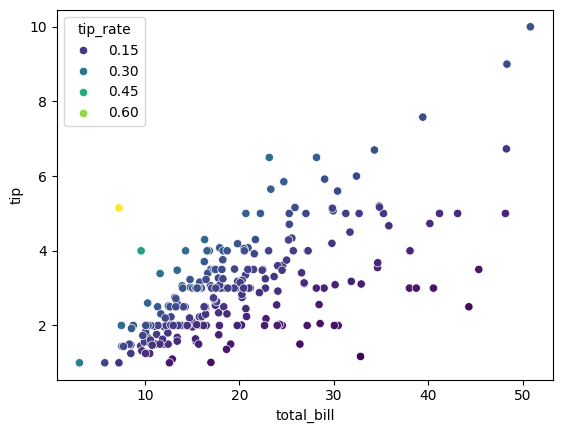

In [317]:
tip_rate = propinas.eval("tip/total_bill").rename("tip_rate")

sns.scatterplot(data=propinas, x="total_bill", y="tip", hue=tip_rate, palette="viridis")

In [318]:
from sklearn.linear_model import LinearRegression

CALCULAR LA REGRESION LINEAL, CORRELACION, DETERMINACION DE PEARSON

In [319]:
#VARIABLES
X = propinas["total_bill"].values.reshape(-1, 1)
Y = propinas["tip"].values

In [320]:
#CORRELACION DE PEARSON
r = np.corrcoef(propinas["total_bill"], propinas["tip"])[0,1]
print("coeficiente de correlacion es: ", r)

coeficiente de correlacion es:  0.6757341092113645


In [321]:
#REGRESION LINEAL SIMPLE
modelo = LinearRegression().fit(X, Y)
r2 = modelo.score(X, Y)
print("coeficiente de determinacion r2:", r2)

coeficiente de determinacion r2: 0.45661658635167657


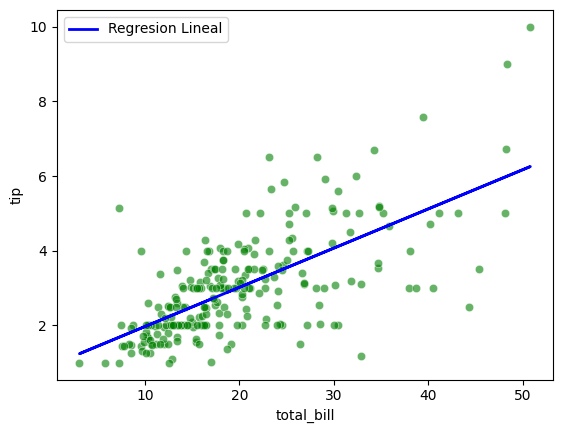

In [322]:
#GRAFICAR
sns.scatterplot(x=propinas["total_bill"], y=propinas["tip"], color="green", alpha=0.6)

plt.plot(propinas["total_bill"], modelo.predict(X), color="blue", linewidth=2, label="Regresion Lineal")

plt.xlabel = "Total de la cuenta (total_bill)"
plt.ylabel = "Propinas (tip)"
plt.title = "Relacion entre total_bill y tip"
plt.legend()
plt.show()


In [323]:
#COEFICIENTE DE LA ECUACION
intercepto = modelo.intercept_
pendiente = modelo.coef_[0]

print("Ecuacion de la recta: tip = {:.2f} + {:.2f} * total_bill".format(intercepto, pendiente))

Ecuacion de la recta: tip = 0.92 + 0.11 * total_bill


In [324]:
#PLO DE PREDICCION
tip_simulated = 200
pred_tip = modelo.predict([[tip_simulated]])
print(f"prediccion de una propina para una cuenta de {tip_simulated}:", pred_tip[0])

prediccion de una propina para una cuenta de 200: 21.925173090425346
